# Reanalysis of stalagmite reported by Schorndorf et al. (2023)
Data is reported by Schorndorf et al. (2023)

#### Reference 

Schorndorf, N., Frank, N., Ritter, S.M., Warken, S.F., Scholz, C., Keppler, F., Scholz, D., Weber, M., Aviles Olguin, J. and Stinnesbeck, W., 2023. Mid-to late Holocene sea-level rise recorded in Hells Bells 234U/238U ratio and geochemical composition. Scientific Reports, 13(1), p.10011.



# Notes on example
Hells Bells are subaqueous speloethems near the Yucatán Peninsula. The authors argue that Hells Bells formed semi-continuously in response to the interaction of sea-level rise, salinity, and aquifier hydrology. The authors say that sea-level rise is recorded in the $^{234}$U/$^{238}$U ratio and the associated geochemistry. 

The nature of the Hells Bells speleothems might make them an interesting sample to apply the IBIS model framework to. In the reported data the authors assume an initial $^{230}$Th/$^{232}$Th activity ratio of 2 $\pm$ 1. Elevated relative to the average upper crust, $\sim$ 0.8 in activity space, with a realtive uncertainy of 50%. 

Here we carry through the IBIS analytical method and then look at the outputs. The sample analyzed here is El Zapote. 




In [15]:
import ibis

In [16]:
from ibis import IBIS_Main

In [17]:
_META = dict(
        # depth handling
        depth_increases_down=True,
        depth_tol=0.0,  # 0 => no rounding

        # boutique sampler
        fraction_det=0.2,
        r02_clip_lo=0.001,
        r02_clip_hi=1000.0,

        # r02 max bound from data (IMPORTANT)
        r02_max_k_sigma=3.0,  # use (r08+kσ)/(r28-kσ)

        # r02 relative uncertainty proposal
        r02_err_mode="halfnorm",   # "fixed"|"uniform"|"halfnorm"
        r02_rel_err=0.25,
        r02_rel_min=0.005,
        r02_rel_max=1.0,

        # validity gates
        age_sigma_gate=2.0,
        age_eps=1e-12,

        # sigma cheating prevention (EB): default False
        use_r02_in_sigma=True,

        # batch sampler controls
        batch_size = 1000,
        max_batches=5000,
        keep_frac=0.08,
        keep_factor=8,

        # layer windows
        neighbors=1,

        # pair weighting
        pair_weight_mode="exp",   # "none"|"exp"|"power"
        pair_tau_layers=2.0,
        pair_alpha=1.0,
        min_pair_weight=1e-6,

        # prior mixture
        global_mass=0.9999,
        n_samples_global=4000,
        n_samples_layer=1000,

        # KDE fit controls
        kde_beta=0.8,
        bw_grid=None,
        cv=5,
        bw_subsample=3000,
        grid_n=1200,
        hi_pct=99.9,
        floor_pdf=1e-12,
    Verbose = True
    )

In [18]:
mm = IBIS_Main.IBIS('/Users/johncarter/Desktop/Schorndorf_2023_IBIS_Input.xlsx',
    sample_name='Schorndorf_2023',          
    MCMC_samples=2000000,
    MCMC_burn_in=1000000,
    MCMC_Strat_samples=3000000,
    n_chains=3,
    Start_from_pickles=True, 
    show_bird=False, 
    method='thoth',
    strat_resolution=100, 
                    diction_meta= _META
)
 

Data loaded successfully from /Users/johncarter/Desktop/Schorndorf_2023_IBIS_Input.xlsx (Excel)
All results will save to: /Users/johncarter/Desktop/Schorndorf_2023_folder


In [19]:
mm.Set_Up_MCMC()

Ages, uncertainties, and maximum age saved to /Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_bounds.pkl
Bounds and uncertainties computed and saved.
[thoth] batch 1/5000: valid=954 kept_total=77 (r02_hi=997.6)
[thoth] batch 101/5000: valid=931 kept_total=7660 (r02_hi=997.6)
[thoth] batch 201/5000: valid=950 kept_total=15250 (r02_hi=997.6)
[thoth] batch 301/5000: valid=942 kept_total=22839 (r02_hi=997.6)
[thoth] batch 401/5000: valid=934 kept_total=30426 (r02_hi=997.6)
Initial thorium composition prior saved to /Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_prior.pkl
Computed & saved Thorium prior to
 /Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_prior.pkl


(0.0, 24.0)

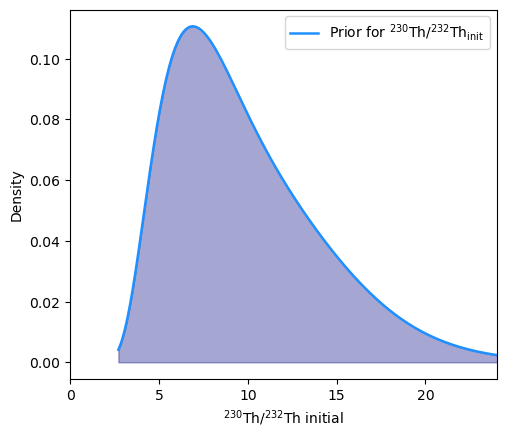

In [22]:
fig, ax =mm.Plot_Priors()
ax.set_xlim(0, 24)

In [23]:
mm.Run_MCMC()

Generating new starting θ’s


Chain 0:   4%|▍         | 114052/3000000 [00:58<24:45, 1942.38it/s]


================ MCMC diagnostics @ iter 5000 ================
overall acc          : 0.243
accepted             : 1214
invalid_theta        : 0
age_nan              : 0
lp_nan               : 0
mh_reject            : 3786
sat_frac             : 0.000
worst_adj_violation  : i=30, j=31, Δ=-30.7665, z=-0.138231


--- block tuning snapshot ---
Block scales           median=0.06601  min=0.05992  max=0.08963

--- single-move tuning snapshot ---
Initial_Thorium_     median=0.1813  min=0.08089  max=0.3303
U234_U238_ratios_    median=0.03878  min=0.01152  max=0.1177
Th230_U238_ratios_   median=0.005914  min=0.002384  max=0.02857
Th232_U238_ratios_   median=0.01682  min=0.0002729  max=0.06731

--- worst indices (top 8) ---
idx= 32  total=   142  fail=   117  acc=    25
idx= 33  total=   132  fail=   117  acc=    15
idx=  6  total=   143  fail=   113  acc=    30
idx= 21  total=   146  fail=   110  acc=    36
idx= 29  total=   141  fail=   110  acc=    31
idx= 15  total=   141  fail=   109  acc=

Chain 0:   6%|▋         | 189969/3000000 [01:37<24:08, 1939.30it/s]

idx= 27  total=  1912  fail=  1570  acc=   342
idx= 24  total=  1988  fail=  1545  acc=   443

================ MCMC diagnostics @ iter 80000 ================
overall acc          : 0.242
accepted             : 19333
invalid_theta        : 0
age_nan              : 0
lp_nan               : 0
mh_reject            : 60667
sat_frac             : 0.000
worst_adj_violation  : none


--- block tuning snapshot ---
Block scales           median=0.0154  min=0.005123  max=0.03864

--- single-move tuning snapshot ---
Initial_Thorium_     median=0.906  min=0.2377  max=1
U234_U238_ratios_    median=0.04652  min=0.01431  max=0.2409
Th230_U238_ratios_   median=0.01275  min=0.007576  max=0.04219
Th232_U238_ratios_   median=0.0318  min=0.0006598  max=0.1054

--- worst indices (top 8) ---
idx= 38  total=  2106  fail=  1731  acc=   375
idx= 32  total=  2144  fail=  1719  acc=   425
idx= 30  total=  2071  fail=  1717  acc=   354
idx= 35  total=  2071  fail=  1715  acc=   356
idx= 31  total=  2115  fail=  1

...

Initial_Thorium_     median=0.9691  min=0.2493  max=1
U234_U238_ratios_    median=0.05299  min=0.01543  max=0.2532
Th230_U238_ratios_   median=0.01467  min=0.008088  max=0.04644
Th232_U238_ratios_   median=0.03654  min=0.000761  max=0.1156

--- worst indices (top 8) ---
idx= 36  total= 69494  fail= 49677  acc= 19817
idx= 28  total= 69849  fail= 49374  acc= 20475
idx= 31  total= 69636  fail= 49355  acc= 20281
idx= 24  total= 69977  fail= 49316  acc= 20661
idx= 33  total= 70190  fail= 49182  acc= 21008
idx= 29  total= 69759  fail= 49180  acc= 20579
idx= 22  total= 69904  fail= 49169  acc= 20735
idx= 23  total= 69996  fail= 49050  acc= 20946

================ MCMC diagnostics @ iter 2730000 ================
overall acc          : 0.309
accepted             : 843518
invalid_theta        : 0
age_nan              : 19
lp_nan               : 0
mh_reject            : 1886463
sat_frac             : 0.000
worst_adj_violation  : i=30, j=31, Δ=-26.913, z=-0.120918


--- block tuning snapshot ---
B

Chain 0:  97%|█████████▋| 2909917/3000000 [25:00<00:46, 1934.16it/s]


================ MCMC diagnostics @ iter 2800000 ================
overall acc          : 0.309
accepted             : 865420
invalid_theta        : 0
age_nan              : 19
lp_nan               : 0
mh_reject            : 1934561
sat_frac             : 0.000
worst_adj_violation  : i=25, j=26, Δ=-19.8674, z=-0.0999391


--- block tuning snapshot ---
Block scales           median=0.01378  min=0.001317  max=0.03787

--- single-move tuning snapshot ---
Initial_Thorium_     median=0.9691  min=0.2493  max=1
U234_U238_ratios_    median=0.05299  min=0.01543  max=0.2532
Th230_U238_ratios_   median=0.01467  min=0.008088  max=0.04644
Th232_U238_ratios_   median=0.03654  min=0.000761  max=0.1156

--- worst indices (top 8) ---
idx= 36  total= 71431  fail= 51058  acc= 20373
idx= 28  total= 71775  fail= 50679  acc= 21096
idx= 31  total= 71518  fail= 50665  acc= 20853
idx= 24  total= 71846  fail= 50654  acc= 21192
idx= 22  total= 71802  fail= 50512  acc= 21290
idx= 33  total= 72066  fail= 50489  ac

Chain 0:  99%|█████████▉| 2979708/3000000 [25:36<00:10, 1934.28it/s]

idx= 33  total= 73896  fail= 51741  acc= 22155
idx= 29  total= 73425  fail= 51739  acc= 21686
idx= 22  total= 73559  fail= 51725  acc= 21834
idx=  3  total= 73631  fail= 51703  acc= 21928

================ MCMC diagnostics @ iter 2875000 ================
overall acc          : 0.309
accepted             : 888757
invalid_theta        : 0
age_nan              : 21
lp_nan               : 0
mh_reject            : 1986222
sat_frac             : 0.000
worst_adj_violation  : i=21, j=22, Δ=-25.8741, z=-0.184723


--- block tuning snapshot ---
Block scales           median=0.01378  min=0.001317  max=0.03787

--- single-move tuning snapshot ---
Initial_Thorium_     median=0.9691  min=0.2493  max=1
U234_U238_ratios_    median=0.05299  min=0.01543  max=0.2532
Th230_U238_ratios_   median=0.01467  min=0.008088  max=0.04644
Th232_U238_ratios_   median=0.03654  min=0.000761  max=0.1156

--- worst indices (top 8) ---
idx= 36  total= 73393  fail= 52478  acc= 20915
idx= 24  total= 73858  fail= 52108  acc

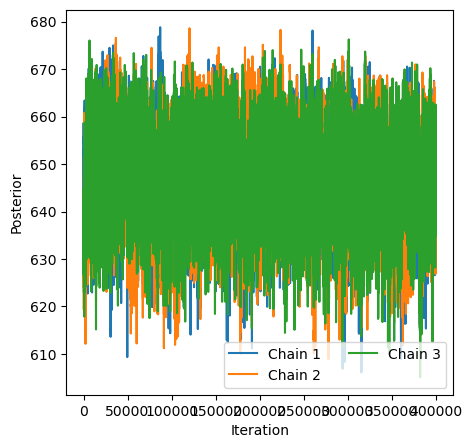

In [24]:
# Plot the posterior 
# always recommend having a lot at it
# Then another convergence tester is to look at the r-hat values
# This we do below. 
mm.Posterior_plot()

In [87]:
# Save the summary so we can read it back in and plot it anywhere in any style we'd like
mm.SaveSummary()

IBIS summary saved to: /Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_ibis_summary.csv
Summary saved to Schorndorf_2023_ibis_summary.csv


In [27]:
"""
Inside the IBIS model you can grab the instance of the initial thorium
MCMC model using .Ibis_Chains then you can access other functions. 
In particular it is useful to look at the chain diagnostics 
"""
mm.Ibis_Chains.Chain_diag_dataframe()

,Sample index (top to bottom),Initial thorium r-hat,234U_238U r-hat,232Th_238U r-hat,230Th_238U r-hat
0,1,1.000564,1.000260,1.000018,1.000003
1,2,1.000510,1.000327,1.000004,1.000008
2,3,1.000057,1.000178,1.000010,1.000033
3,4,1.000375,1.000708,1.000014,1.000016
4,5,1.006398,1.003692,1.000028,1.000089
5,6,1.000052,1.002428,1.000065,1.000103
6,7,1.000384,1.000366,1.000090,1.000002
7,8,1.000420,1.000477,1.000006,1.000008
8,9,1.000588,1.000007,1.000074,1.000022
9,10,1.001138,1.000312,1.000034,1.000022


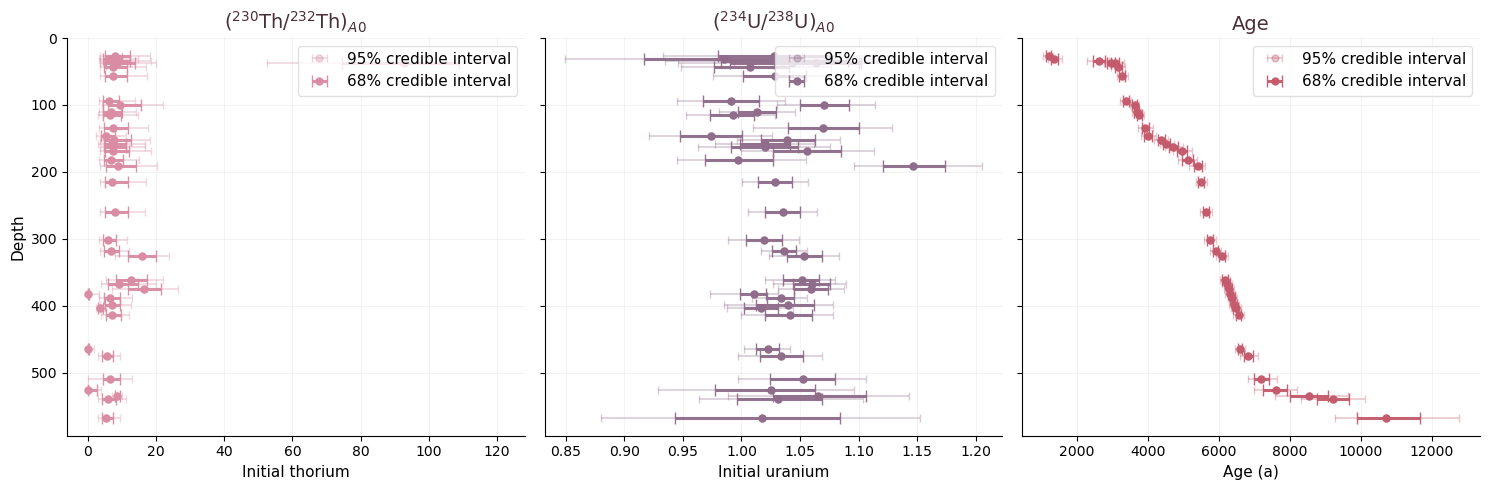

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#
# Read the data back in that we saved above
#
df_summary = pd.read_csv("/Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_ibis_summary.csv")


# -----------------------------------
# Wes Anderson colors - https://github.com/hneutr/wesanderson
# -----------------------------------
gbh_colors = {
    "thorium": "#D98CA3",   # dusty pink
    "uranium": "#8E6C8A",   # mauve-purple
    "age": "#C45B6D",       # warm rose-red
    "light": "#F4E7D3",     # cream
    "dark": "#4B2E39"       # deep plum
}

# -----------------------------------
# Figure setup
# -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.patch.set_facecolor("white")

# -----------------------------------
# Plot settings for each panel
# -----------------------------------
plot_info = [
    {
        "ax": axes[0],
        "x": "initial thorium",
        "xerr68": ["Th0_err_lo68", "Th0_err_hi68"],
        "xerr95": ["Th0_err_lo95", "Th0_err_hi95"],
        "title": "($^{230}$Th/$^{232}$Th)$_{A0}$",
        "xlabel": "Initial thorium",
        "color": gbh_colors["thorium"]
    },
    {
        "ax": axes[1],
        "x": "initial uranium",
        "xerr68": ["U0_err_lo68", "U0_err_hi68"],
        "xerr95": ["U0_err_lo95", "U0_err_hi95"],
        "title": "($^{234}$U/$^{238}$U)$_{A0}$",
        "xlabel": "Initial uranium",
        "color": gbh_colors["uranium"]
    },
    {
        "ax": axes[2],
        "x": "age",
        "xerr68": ["age_err_lo68", "age_err_hi68"],
        "xerr95": ["age_err_lo95", "age_err_hi95"],
        "title": "Age",
        "xlabel": "Age (a)",
        "color": gbh_colors["age"]
    }
]

# -----------------------------------
# Make the plots
# -----------------------------------
for item in plot_info:
    ax = item["ax"]
    x = df_summary[item["x"]]
    y = df_summary["Depth_Meas"]

    xerr68 = np.vstack([
        df_summary[item["xerr68"][0]],
        df_summary[item["xerr68"][1]]
    ])

    xerr95 = np.vstack([
        df_summary[item["xerr95"][0]],
        df_summary[item["xerr95"][1]]
    ])

    # 95% intervals first (lighter, behind)
    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr95,
        fmt='o',
        ms=5,
        lw=1.2,
        capsize=3,
        color=item["color"],
        alpha=0.35,
        label='95% credible interval',
        zorder=1
    )

    # 68% intervals on top (stronger)
    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr68,
        fmt='o',
        ms=5,
        lw=2.2,
        capsize=4,
        color=item["color"],
        alpha=0.95,
        label='68% credible interval',
        zorder=2
    )

    ax.set_title(item["title"], fontsize=14, color=gbh_colors["dark"])
    ax.set_xlabel(item["xlabel"], fontsize=11)
    ax.invert_yaxis()
    ax.grid(alpha=0.15)
    ax.legend(frameon=True, facecolor="white", edgecolor="0.85", fontsize=11, 
             loc = 'upper right')

axes[0].set_ylabel("Depth", fontsize=11)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Lets make some nice plots 
* Z-scored initial thorium and initial uranium on the same age axis

* I'll use a Gaussian smoothing kernel to keep the general properties of the data but smooth the relationship for nice visuals

* Going to remove the relatively high initial thorium value > 50, just for visualization

In [89]:
# =========================================================
# Helper function - data from IBIS is likely to assymetric so we 
# want to sample both left and right uncertainties
# =========================================================
def sample_split_normal(mu, sig_lo, sig_hi, rng):
    mu = np.asarray(mu, dtype=float)
    sig_lo = np.asarray(sig_lo, dtype=float)
    sig_hi = np.asarray(sig_hi, dtype=float)

    p_left = sig_lo / (sig_lo + sig_hi + 1e-15)
    u = rng.random(mu.shape)
    left = u < p_left

    z = np.abs(rng.normal(size=mu.shape))
    out = mu.copy()
    out[left]  = mu[left]  - z[left]  * sig_lo[left]
    out[~left] = mu[~left] + z[~left] * sig_hi[~left]
    return out


# =========================================================
# Guassian kernel smoother
# =========================================================
def kernel_smoother(x_grid, x, y, bandwidth):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    yhat = np.full_like(x_grid, np.nan, dtype=float)

    for i, x0 in enumerate(x_grid):
        w = np.exp(-0.5 * ((x - x0) / bandwidth)**2)
        sw = np.sum(w)
        if sw > 0:
            yhat[i] = np.sum(w * y) / sw

    return yhat


# =========================================================
# Monte Carlo method
# =========================================================
def mc_smooth_envelope(age, age_lo, age_hi,
                       y, y_lo, y_hi,
                       x_grid=None,
                       n_mc=2000,
                       bandwidth=None,
                       random_seed=42):
    rng = np.random.default_rng(random_seed)

    age = np.asarray(age, dtype=float)
    age_lo = np.asarray(age_lo, dtype=float)
    age_hi = np.asarray(age_hi, dtype=float)
    y = np.asarray(y, dtype=float)
    y_lo = np.asarray(y_lo, dtype=float)
    y_hi = np.asarray(y_hi, dtype=float)

    y_mean = np.nanmean(y)
    y_std = np.nanstd(y, ddof=1)
    y_z = (y - y_mean) / y_std
    yerr_z = np.vstack([y_lo / y_std, y_hi / y_std])

    if x_grid is None:
        xmin = np.nanmin(age - age_lo)
        xmax = np.nanmax(age + age_hi)
        x_grid = np.linspace(xmin, xmax, 300)


    curves = np.full((n_mc, x_grid.size), np.nan)

    for i in range(n_mc):
        age_s = sample_split_normal(age, age_lo, age_hi, rng)
        y_s   = sample_split_normal(y, y_lo, y_hi, rng)

        y_s_z = (y_s - y_mean) / y_std
        curves[i, :] = kernel_smoother(x_grid, age_s, y_s_z, bandwidth)

    p2_5, p16, p50, p84, p97_5 = np.nanpercentile(
        curves, [2.5, 16, 50, 84, 97.5], axis=0
    )

    return {
        "x_grid": x_grid,
        "median": p50,
        "lo68": p16,
        "hi68": p84,
        "lo95": p2_5,
        "hi95": p97_5,
        "y_z": y_z,
        "yerr_z": yerr_z,
    }


In [90]:
# filter out that really high point - better visual 
df_summary = df_summary[df_summary["initial thorium"] <= 40].copy()

age     = df_summary["age"].values
age_lo  = df_summary["age_err_lo68"].values
age_hi  = df_summary["age_err_hi68"].values

th      = df_summary["initial thorium"].values
th_lo   = df_summary["Th0_err_lo68"].values
th_hi   = df_summary["Th0_err_hi68"].values

u       = df_summary["initial uranium"].values
u_lo    = df_summary["U0_err_lo68"].values
u_hi    = df_summary["U0_err_hi68"].values

# =========================================================
# Make common age grid
# =========================================================
xmin = np.nanmin(age - age_lo)
xmax = np.nanmax(age + age_hi)
x_grid = np.linspace(xmin, xmax, 350)
bandwidth = 0.10 * (xmax - xmin)

# =========================================================
# Monte Carlo out the smoothed envelopes
# =========================================================
res_th = mc_smooth_envelope(
    age, age_lo, age_hi,
    th, th_lo, th_hi,
    x_grid=x_grid,
    n_mc=2000,
    bandwidth=50,
    random_seed=123
)

res_u = mc_smooth_envelope(
    age, age_lo, age_hi,
    u, u_lo, u_hi,
    x_grid=x_grid,
    n_mc=2000,
    bandwidth=50,
    random_seed=123
)



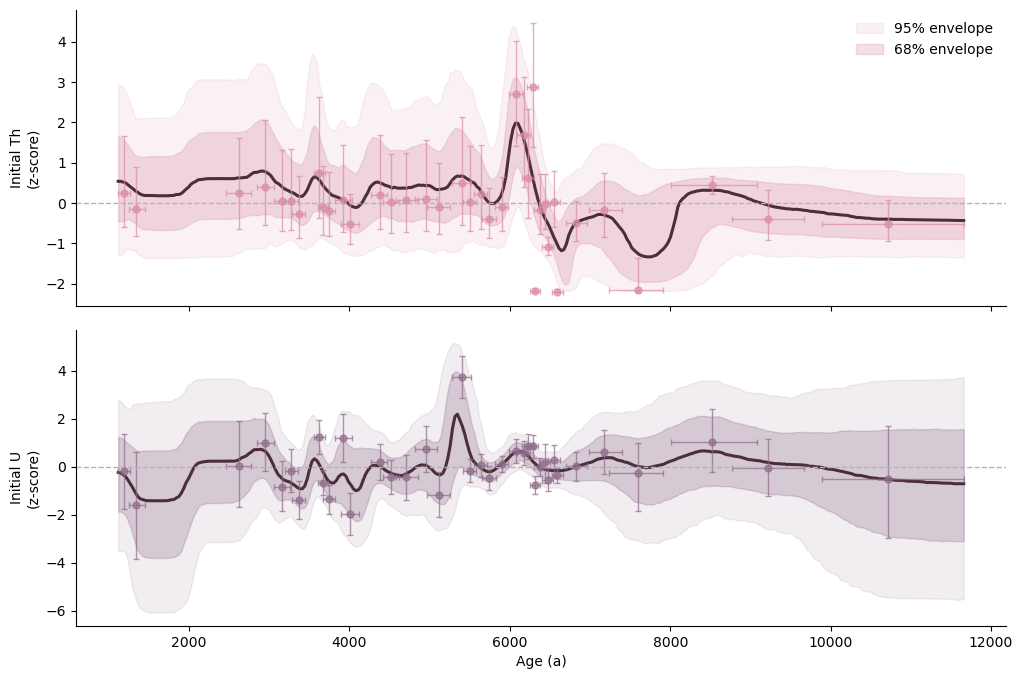

In [91]:
# =========================================================
# Make the Plot
# =========================================================
thor_color = "#D98CA3"
uran_color = "#8E6C8A"
dark_line  = "#4B2E39"

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"hspace": 0.08}
)

# ---------------------------
# Panel 1: Initial thorium
# ---------------------------
ax = axes[0]
ax.fill_between(res_th["x_grid"], res_th["lo95"], res_th["hi95"],
                color=thor_color, alpha=0.12, label="95% envelope")
ax.fill_between(res_th["x_grid"], res_th["lo68"], res_th["hi68"],
                color=thor_color, alpha=0.28, label="68% envelope")
ax.plot(res_th["x_grid"], res_th["median"], color=dark_line, lw=2.2)

ax.errorbar(
    age, res_th["y_z"],
    xerr=np.vstack([age_lo, age_hi]),
    yerr=res_th["yerr_z"],
    fmt="o", ms=5,
    color=thor_color,
    ecolor=thor_color,
    alpha=0.7, capsize=2, lw=1
)

ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_ylabel("Initial Th\n(z-score)")
ax.legend(frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------
# Panel 2: Initial uranium
# ---------------------------
ax = axes[1]
ax.fill_between(res_u["x_grid"], res_u["lo95"], res_u["hi95"],
                color=uran_color, alpha=0.12, label="95% envelope")
ax.fill_between(res_u["x_grid"], res_u["lo68"], res_u["hi68"],
                color=uran_color, alpha=0.28, label="68% envelope")
ax.plot(res_u["x_grid"], res_u["median"], color=dark_line, lw=2.2)

ax.errorbar(
    age, res_u["y_z"],
    xerr=np.vstack([age_lo, age_hi]),
    yerr=res_u["yerr_z"],
    fmt="o", ms=5,
    color=uran_color,
    ecolor=uran_color,
    alpha=0.7, capsize=2, lw=1
)

ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_ylabel("Initial U\n(z-score)")
ax.set_xlabel("Age (a)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Z-score')

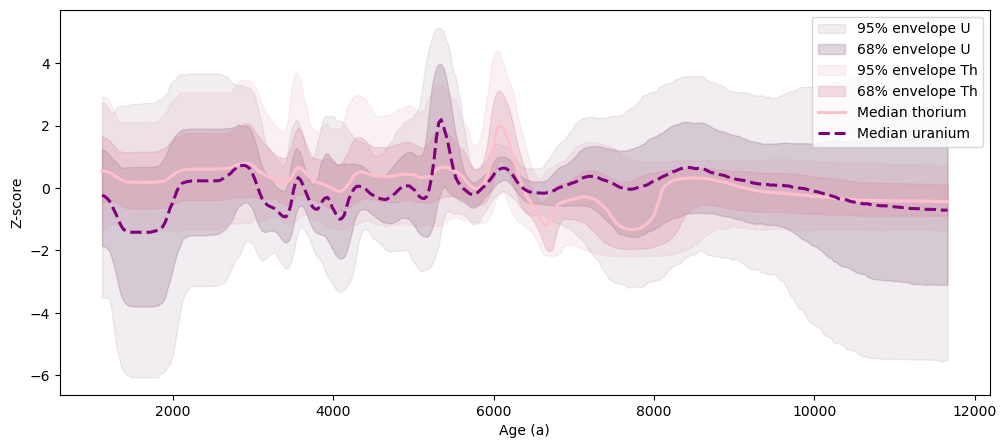

In [92]:
# Stack the Z-scores
fig, axes = plt.subplots(
    1, 1, figsize=(12, 5)
)

axes.fill_between(res_u["x_grid"], res_u["lo95"], res_u["hi95"],
                color=uran_color, alpha=0.12, label="95% envelope U")
axes.fill_between(res_u["x_grid"], res_u["lo68"], res_u["hi68"],
                color=uran_color, alpha=0.28, label="68% envelope U")

axes.fill_between(res_th["x_grid"], res_th["lo95"], res_th["hi95"],
                color=thor_color, alpha=0.12, label="95% envelope Th")
axes.fill_between(res_th["x_grid"], res_th["lo68"], res_th["hi68"],
                color=thor_color, alpha=0.28, label="68% envelope Th")

axes.plot(res_th["x_grid"], res_th["median"], color='pink', lw=2.2, 
         label = 'Median thorium')
axes.plot(res_u["x_grid"], res_u["median"], color='purple', lw=2.2, ls = '--', 
         label = 'Median uranium')

axes.legend()

axes.set_xlabel('Age (a)')
axes.set_ylabel('Z-score')

In [95]:

from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

age = df_summary["age"].values
th  = df_summary["initial thorium"].values
u   = df_summary["initial uranium"].values

# sort by age for LOWESS
order = np.argsort(age)
age_s = age[order]
th_s  = th[order]
u_s   = u[order]

# smooth each against age
th_fit = lowess(th_s, age_s, frac=0.3, return_sorted=False)
u_fit  = lowess(u_s, age_s, frac=0.3, return_sorted=False)

# residuals
th_res = th_s - th_fit
u_res  = u_s - u_fit

# correlate residuals
r_p, p_p = pearsonr(th_res, u_res)
r_s, p_s = spearmanr(th_res, u_res)

print("Residual Pearson r =", r_p, "p =", p_p)
print("Residual Spearman rho =", r_s, "p =", p_s)

Residual Pearson r = 0.4002731616044794 p = 0.012770204170273055
Residual Spearman rho = 0.8409016303753145 p = 3.907902255296782e-11


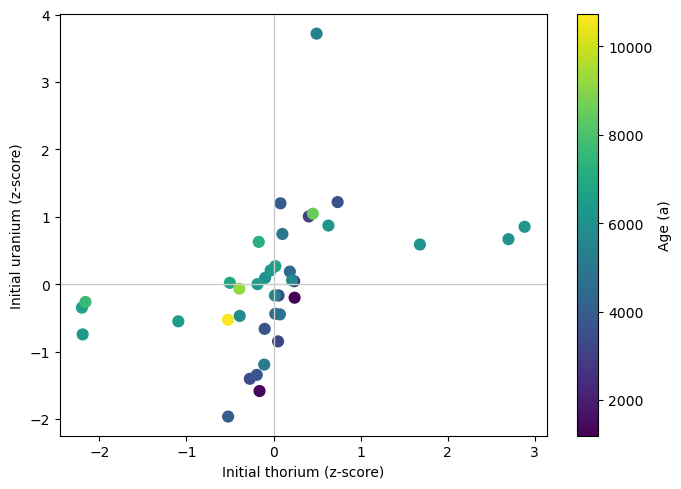

In [96]:
th = df_summary["initial thorium"].values
u  = df_summary["initial uranium"].values
age = df_summary["age"].values

th_z = (th - np.mean(th)) / np.std(th, ddof=1)
u_z  = (u  - np.mean(u))  / np.std(u, ddof=1)

plt.figure(figsize=(7,5))
sc = plt.scatter(th_z, u_z, c=age, s=60)
plt.xlabel("Initial thorium (z-score)")
plt.ylabel("Initial uranium (z-score)")
plt.colorbar(sc, label="Age (a)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.tight_layout()
plt.show()

In [98]:
def sample_split_normal(mu, sig_lo, sig_hi, rng):
    mu = np.asarray(mu, float)
    sig_lo = np.asarray(sig_lo, float)
    sig_hi = np.asarray(sig_hi, float)

    p_left = sig_lo / (sig_lo + sig_hi + 1e-15)
    left = rng.random(mu.shape) < p_left
    z = np.abs(rng.normal(size=mu.shape))

    out = mu.copy()
    out[left]  = mu[left]  - z[left]  * sig_lo[left]
    out[~left] = mu[~left] + z[~left] * sig_hi[~left]
    return out

rng = np.random.default_rng(42)

th  = df_summary["initial thorium"].values
u   = df_summary["initial uranium"].values

th_lo = df_summary["Th0_err_lo68"].values
th_hi = df_summary["Th0_err_hi68"].values
u_lo  = df_summary["U0_err_lo68"].values
u_hi  = df_summary["U0_err_hi68"].values

rvals = []
for _ in range(5000):
    th_s = sample_split_normal(th, th_lo, th_hi, rng)
    u_s  = sample_split_normal(u,  u_lo,  u_hi,  rng)
    r, _ = spearmanr(th_s, u_s)
    rvals.append(r)

rvals = np.array(rvals)
print("Median rho =", np.nanmedian(rvals))
print("68% interval =", np.nanpercentile(rvals, [16, 84]))
print("95% interval =", np.nanpercentile(rvals, [2.5, 97.5]))

Median rho = 0.2774920669657511
68% interval = [0.13929314 0.41047379]
95% interval = [-0.00080425  0.52927563]


# Results
After removing the shared age trend, residual initial thorium and residual initial uranium remain positively correlated (Pearson r = 0.45, p = 0.004; Spearman ρ = 0.85, p < 10^-10), suggesting that the two parametes co-vary beyong the common dependency on age. 
<br>
### Monte
If we sample the analysis using Monte Carlo uncertainty-propagation analysis also supports a positive correlation, although the overall effect is weaker and dips below zero at the 95% level. So it is more appropriate to say it is likely real but sensitive to the model uncertainties - particular the initial thorium uncertainty as this is in general noisier. 



# Strat part
After running the age model part we can then use the uniquely corrected U-Th ages as the input into the age depth model framework. 

You can play with the inputs here: 

* Resolution - how many points on the age-depth grid do you want (more will make it slower and after a point will be redundant)
* Top age - if speleothem is activity dripping at collection you can add a top age bound (model will treat this as a sort of pseduo "age" point and will need uncertainty-could be months/weeks)

* Top Depth/Bottom depth - you can add in these points and extend the data beyond observation - uncertainties should accrue as you extend away from an observed point - would not recommend in an excessive way because you will have no idea what is going on.

In [ ]:
# Run MCMC strat
mm.Run_MCMC_Strat()

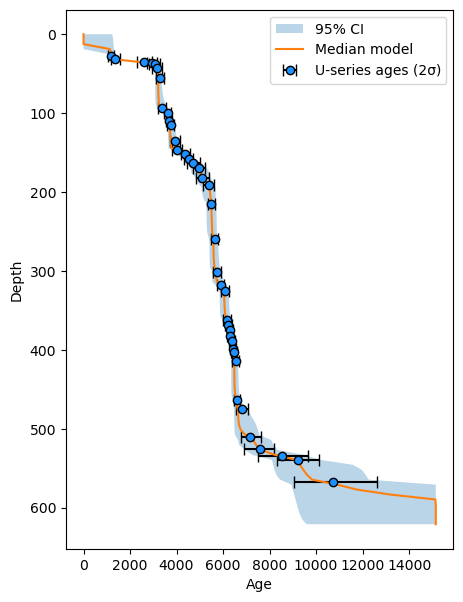

In [32]:
# Plot age depth
mm.Get_Age_Depth_Plot()

In [86]:
# Save the output
# this will be a csv that can be read in anywhere else and plotted again
mm.Save_Age_Depth_Model()

Loaded 3 chains from pickles.


Saved Age-Depth model to: /Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_Age_Depth_Model.csv
Age/Depth model saved to: Schorndorf_2023_Age_Depth_Model.xlsx


In [99]:
# re-plot example
# read in the age depth model we just saved above.
df_age_depth = pd.read_csv("/Users/johncarter/Desktop/Schorndorf_2023_folder/Schorndorf_2023_Age_Depth_Model.csv")

In [100]:
df_age_depth.columns

Index(['Depth', 'Age_Median', 'Age_low_95', 'Age_high_95'], dtype='object')

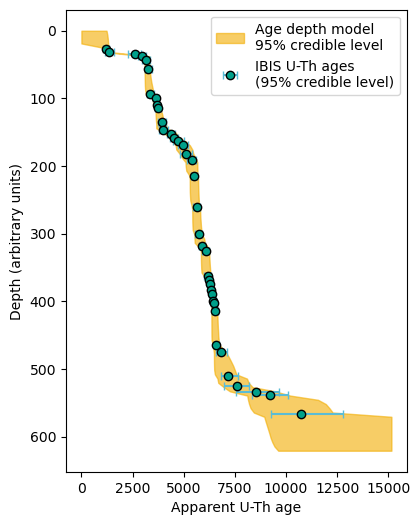

In [114]:
fig, ax = plt.subplots(1, 1, figsize= (4.4, 6))
ax.invert_yaxis()

ax.fill_betweenx(df_age_depth['Depth'], 
                 df_age_depth['Age_low_95'], 
                 df_age_depth['Age_high_95'], 
                color=  "#F2AD00", 
                alpha = 0.6, 
                label = 'Age depth model\n95% credible level')

ax.set_xlabel('Apparent U-Th age')
ax.set_ylabel('Depth (arbitrary units)')

ax.errorbar(y = df_summary['Depth_Meas'],
            x = df_summary['age'], 
            xerr = np.vstack([df_summary['age_err_lo95'], 
                              df_summary['age_err_hi95']]), 
            fmt = 'o', capsize = 3, markerfacecolor = "#00A08A", 
                        markeredgecolor = 'k', zorder = 100, 
           ecolor = "#5BBCD6", 
           label = 'IBIS U-Th ages\n(95% credible level)')

ax.legend(loc = 'upper right')